# **Network Intrusion Detection System**
## **Exploratory Data Analysis (EDA)**

**Dataset:** NSL-KDD  
**Goal:** Understand network traffic patterns and attack types  
**Target:** 5-class classification (Normal, DoS, Probe, R2L, U2R)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Data Loading

In [2]:
BASE_DIR = Path.cwd().parent
df_train = pd.read_csv(BASE_DIR / "data" / "raw" / "KDDTrain+.txt", header=None)
df_test = pd.read_csv(BASE_DIR / "data" / "raw" / "KDDTest+.txt", header=None)

In [3]:
pd.set_option("display.max_columns", None)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
df_train.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42],
      dtype='int64')

## Assign Column Names
>The NSL-KDD dataset is provided without column headers. To make the dataset readable and ready for analysis, we assign the official 43 feature names to both the training and testing datasets before performing exploratory data analysis (EDA).

In [5]:
column_names = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

df_train.columns = column_names
df_test.columns = column_names

df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


 > ## *Observation*

 The official feature names have been successfully assigned to both the training and testing datasets. The datasets are now easier to interpret, and subsequent EDA steps can reference features by their actual names instead of numeric column indices.

## 2. Basic Data Inspection

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [7]:
print("Training Dataset:", df_train.shape)
print("Testing Dataset:", df_test.shape)

Training Dataset: (125973, 43)
Testing Dataset: (22544, 43)


In [8]:
# Missing values — Train
print("Train Missing Values:")
print(df_train.isnull().sum().sum())

# Duplicates
print(f"Train Duplicates: {df_train.duplicated().sum()}")

Train Missing Values:
0
Train Duplicates: 0


In [9]:
df_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.0,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,0.001103,0.302192,0.012669,0.000413,0.004096,0.0,0.000008,0.009423,84.107555,27.737888,0.284485,0.282485,0.119958,0.121183,0.660928,0.063053,0.097322,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,0.045154,24.399618,0.483935,0.022181,0.099370,0.0,0.002817,0.096612,114.508607,72.635840,0.446456,0.447022,0.320436,0.323647,0.439623,0.180314,0.259830,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.0,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


> ## *Observation:*
 Many numerical features are concentrated around low or zero values, while a few features contain extremely large values, indicating skewed distributions and the presence of outliers.


## 3. Outlier Analysis

In [10]:
select_numeric_columns = df_train.select_dtypes(np.number).columns

outliers_result = []


for column in select_numeric_columns:
    Q1 = df_train[column].quantile(0.25)
    Q3 = df_train[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = df_train[
        (df_train[column] < lower_bound) | (df_train[column] > upper_bound)
    ].shape[0]

    outliers_result.append({'Column': column , 'Outliers': outliers})

outliers_df = pd.DataFrame(outliers_result)
outliers_df


,Column,Outliers
0,duration,10018
1,src_bytes,13840
2,dst_bytes,23579
3,land,25
4,wrong_fragment,1090
5,urgent,9
6,hot,2671
7,num_failed_logins,122
8,logged_in,0
9,num_compromised,1286


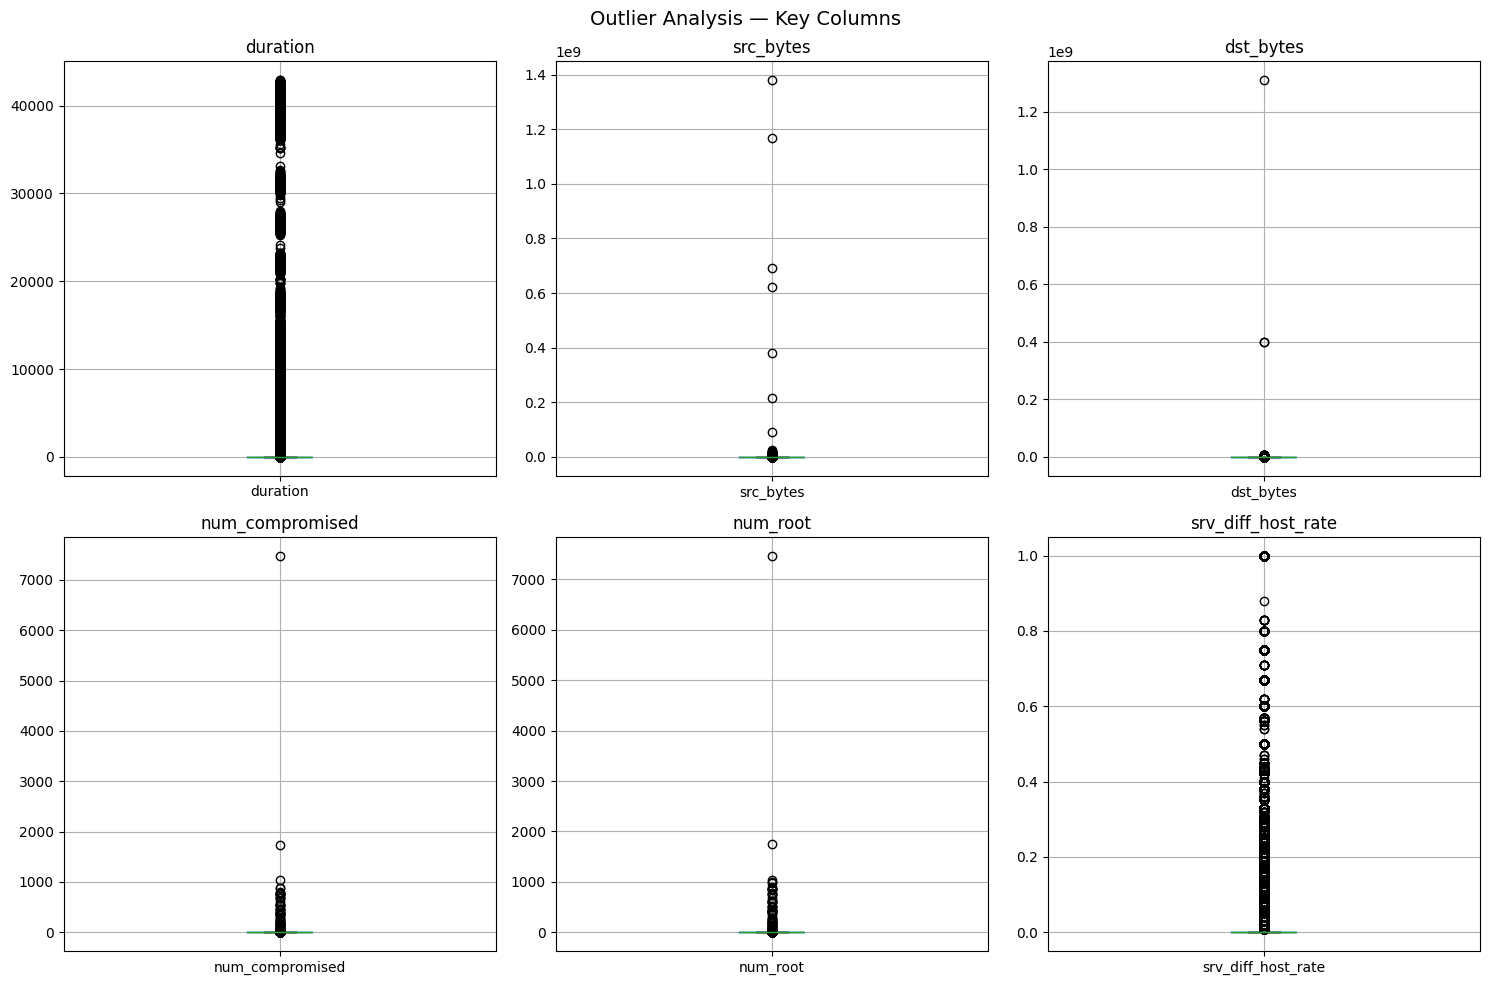

In [11]:
import matplotlib.pyplot as plt

cols_to_plot = ['duration', 'src_bytes', 'dst_bytes',
                'num_compromised', 'num_root', 'srv_diff_host_rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    df_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=12)

plt.suptitle('Outlier Analysis — Key Columns', fontsize=14)
plt.tight_layout()
plt.savefig('../images/outliers_boxplot.png', dpi=150)
plt.show()

In [12]:
print("src_bytes statistics:")
print(f"Q1: {df_train['src_bytes'].quantile(0.25)}")
print(f"Median: {df_train['src_bytes'].quantile(0.50)}")
print(f"Q3: {df_train['src_bytes'].quantile(0.75)}")
print(f"Max: {df_train['src_bytes'].max()}")

src_bytes statistics:
Q1: 0.0
Median: 44.0
Q3: 276.0
Max: 1379963888


> ## *Outlier Analysis Conclusion*
- Outliers exist in `src_bytes`, `dst_bytes`, `duration`, `num_compromised`, `num_root`
- These are **NOT data errors** — they represent real attack behavior (DoS, U2R)
- Log scale box plots confirm extreme right skew in key columns
- Tree-based models handle outliers natively
- **Decision: All outliers retained**

## 4. Feature Distribution 


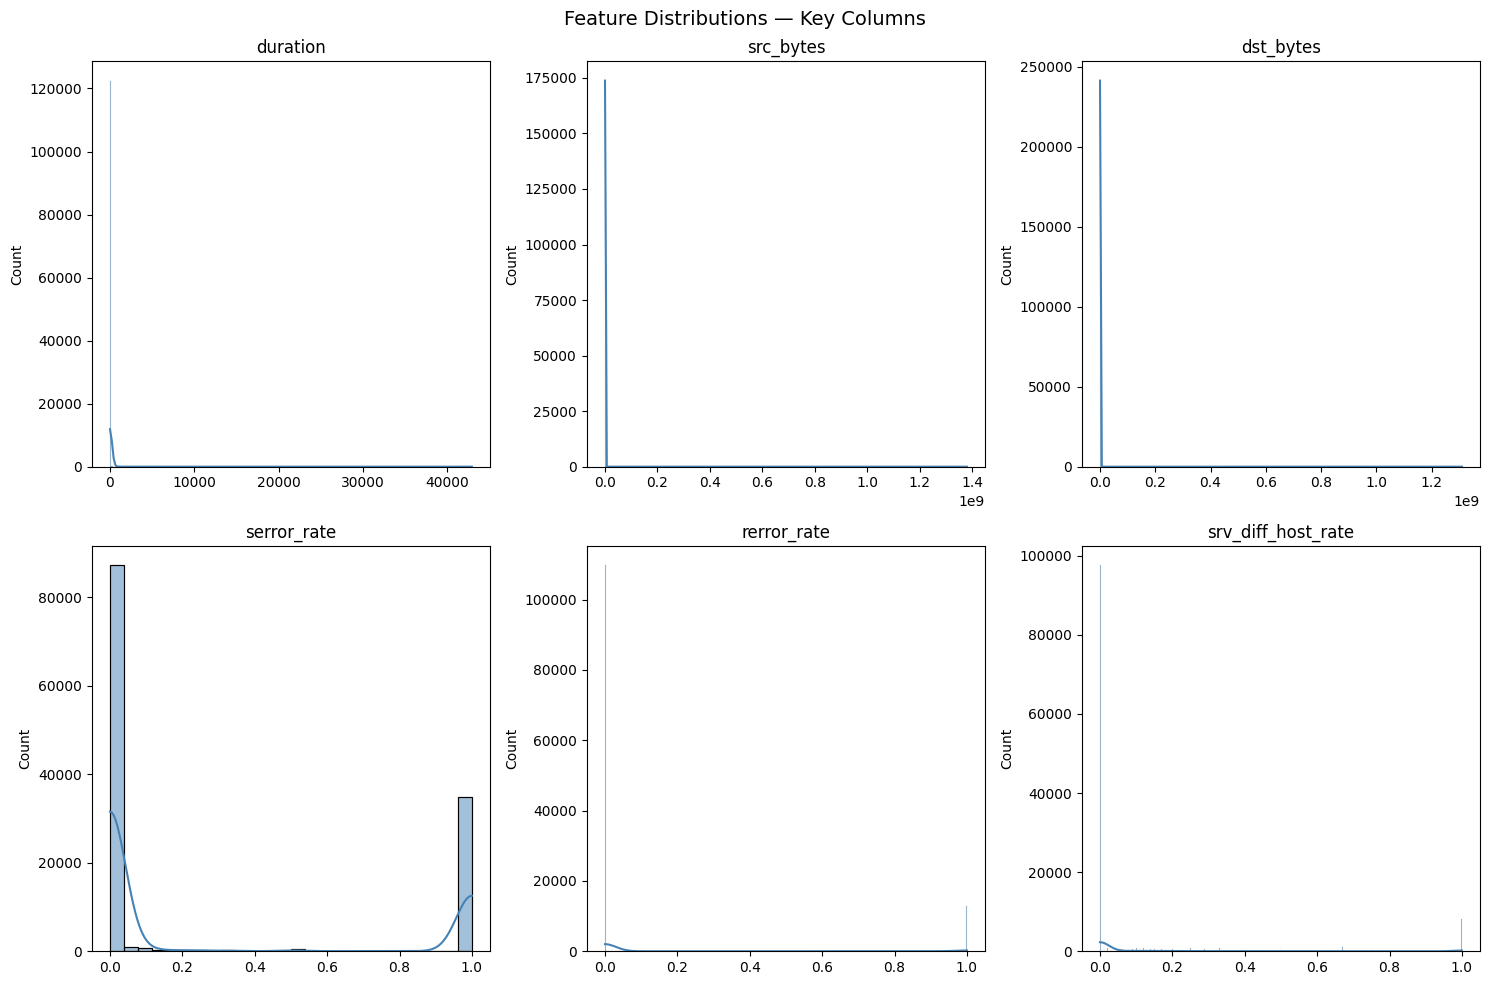

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['duration', 'src_bytes', 'dst_bytes',
        'serror_rate', 'rerror_rate', 'srv_diff_host_rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions — Key Columns', fontsize=14)
plt.tight_layout()
plt.savefig('../images/feature_distributions.png', dpi=150)
plt.show()

 > ## Feature Distribution Conclusion
- All numeric features show **extreme right skew**
- `serror_rate` shows bimodal pattern (0 = Normal, 1 = DoS)
- `rerror_rate` right spread confirms Probe attack pattern
- Distributions clearly separate normal vs attack traffic

## 5. Categorical Features Analysis

In [14]:
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    print(f"\n{col} — {df_train[col].nunique()} unique values:")
    print(df_train[col].value_counts())
    print("---")


protocol_type — 3 unique values:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
---

service — 70 unique values:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64
---

flag — 11 unique values:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64
---


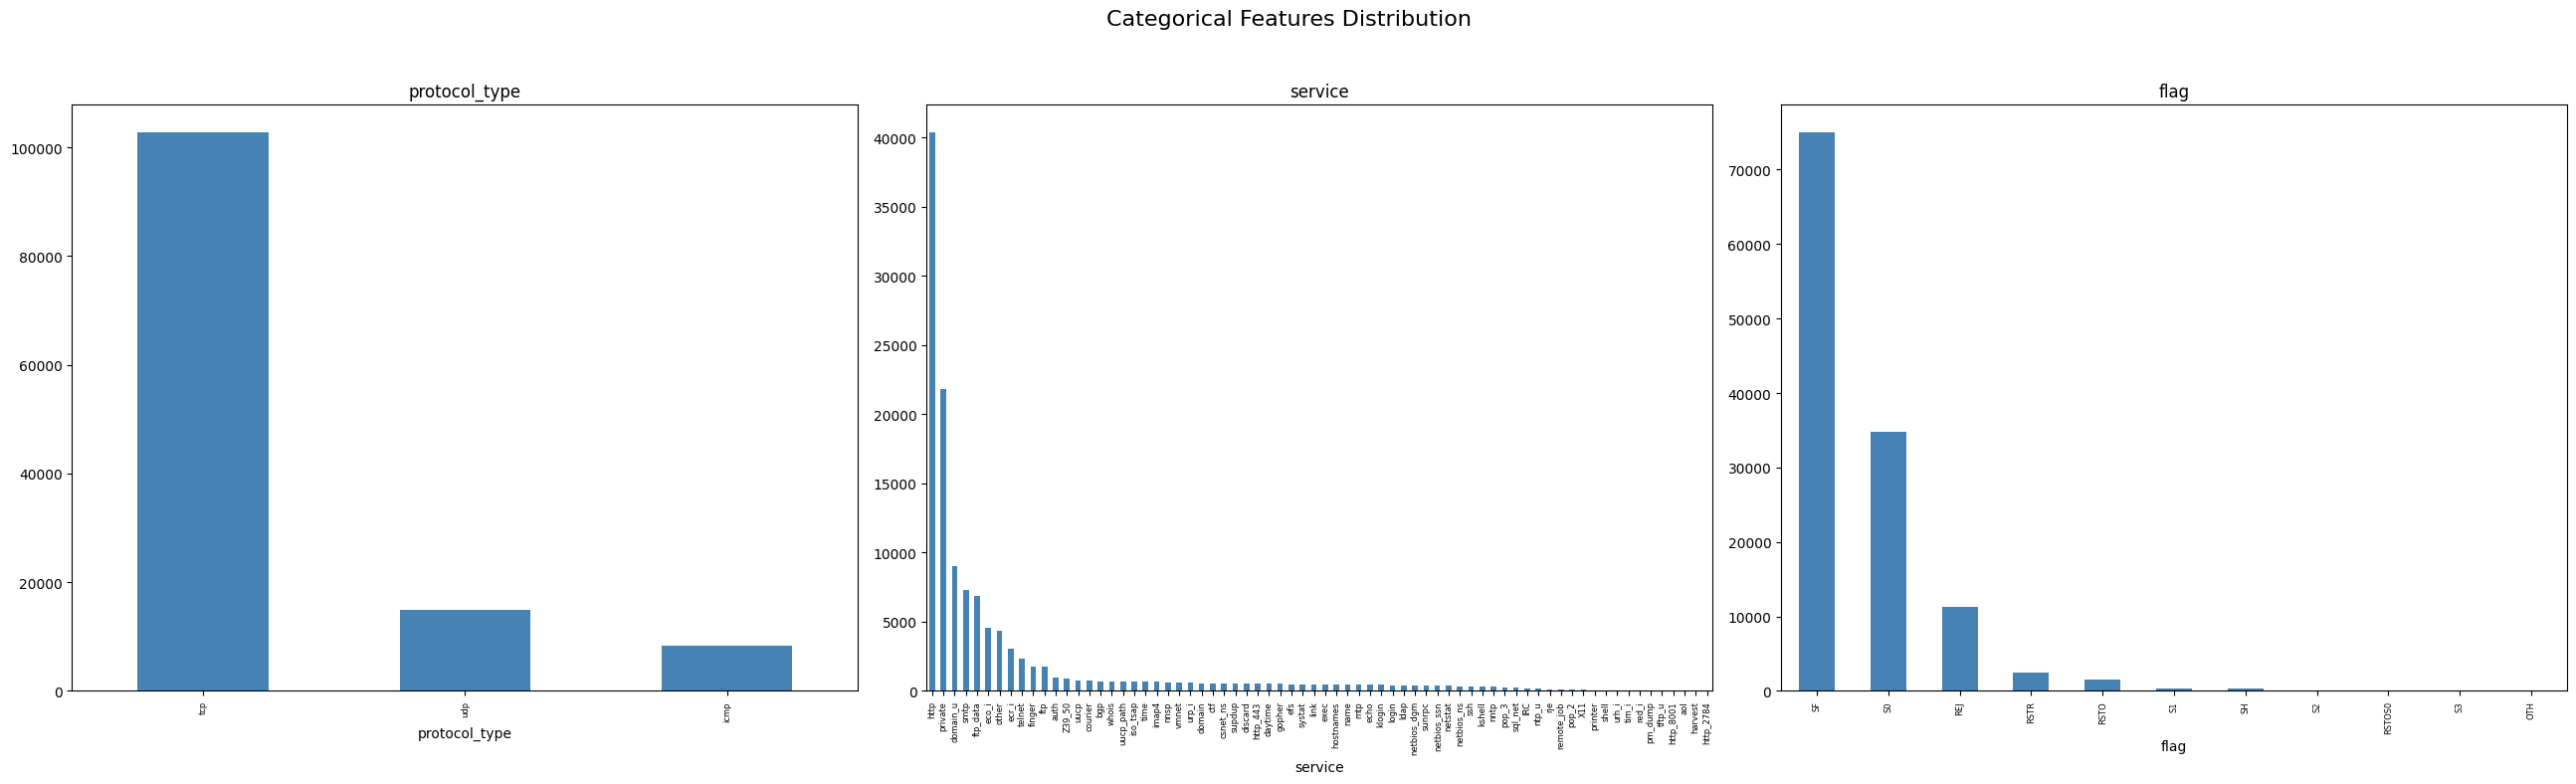

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8))
for i, col in enumerate(cat_cols):
    df_train[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(col, fontsize=12)

    # Rotate x-axis labels
    axes[i].tick_params(axis='x', rotation=90, labelsize=6)

plt.suptitle('Categorical Features Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../images/categorical_distribution.png', dpi=300)
plt.show()

> ## *Categorical Analysis Conclusion*
- `protocol_type`: 3 values — TCP dominant (81%) ✅
- `service`: 70 unique values — `http` and `private` top
- `flag`: 11 values — `SF` (normal) and `S0` (DoS) dominant
- All 3 columns will use **Label Encoding** in preprocessing

## 6. Correlation Analysis

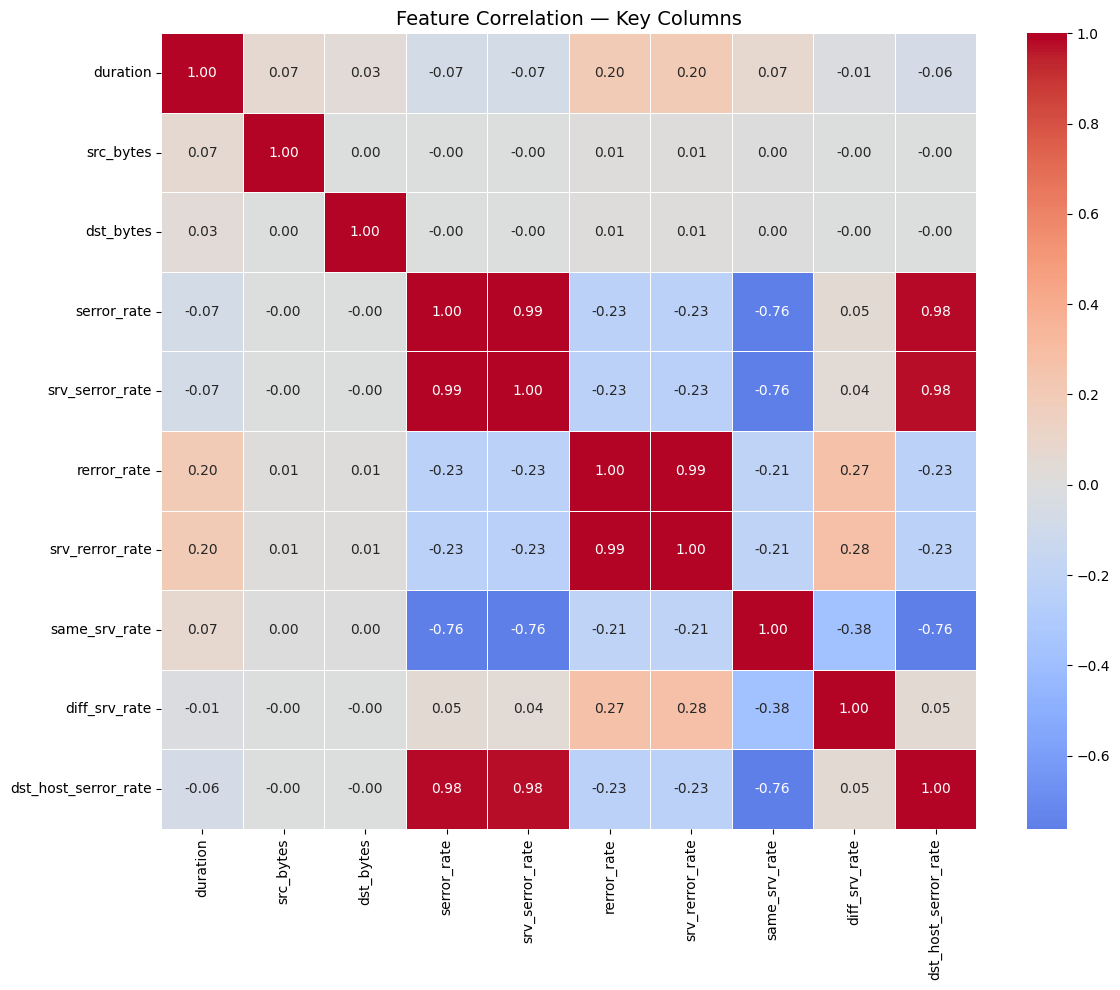

In [16]:
# Select key features
important_cols = [
    'duration', 'src_bytes', 'dst_bytes',
    'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate',
    'dst_host_serror_rate'
]

plt.figure(figsize=(12, 10))

# Plot correlation heatmap
sns.heatmap(
    df_train[important_cols].corr(),
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Feature Correlation — Key Columns', fontsize=14)
plt.tight_layout()

# Save the figure
plt.savefig('../images/correlation_heatmap_key.png', dpi=150)

plt.show()

> ## *Correlation Analysis Conclusion*
- Strong correlations: `serror_rate` ↔ `srv_serror_rate` = 0.99
- Strong correlations: `rerror_rate` ↔ `srv_rerror_rate` = 0.99
- Multicollinearity present but **acceptable** for tree-based models
- No feature dropping required

## 7. Label Distribution & Attack Mapping

In [17]:
print("Original Label Distribution (23 types):")
print(df_train['label'].value_counts())
print(f"\nTotal unique labels: {df_train['label'].nunique()}")

Original Label Distribution (23 types):
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Total unique labels: 23


In [18]:
# Map all attack labels to 5 attack categories
attack_map = {
    'normal': 'Normal',

    # DoS attacks
    'neptune': 'DoS',
    'smurf': 'DoS',
    'pod': 'DoS',
    'teardrop': 'DoS',
    'land': 'DoS',
    'back': 'DoS',
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',

    # Probe attacks
    'satan': 'Probe',
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',

    # R2L attacks
    'warezclient': 'R2L',
    'guess_passwd': 'R2L',
    'warezmaster': 'R2L',
    'imap': 'R2L',
    'ftp_write': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'snmpguess': 'R2L',
    'snmpgetattack': 'R2L',
    'httptunnel': 'R2L',
    'sendmail': 'R2L',
    'named': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'worm': 'R2L',
    'sqlattack': 'R2L',

    # U2R attacks
    'buffer_overflow': 'U2R',
    'rootkit': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'ps': 'U2R',
    'xterm': 'U2R'
}

df_train['attack_type'] = df_train['label'].map(attack_map)
df_test['attack_type'] = df_test['label'].map(attack_map)

print("Attack Type Distribution:")
print(df_train['attack_type'].value_counts())
print(f"\nTrain missing: {df_train['attack_type'].isna().sum()}")
print(f"Test missing:  {df_test['attack_type'].isna().sum()}")

Attack Type Distribution:
attack_type
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Train missing: 0
Test missing:  0


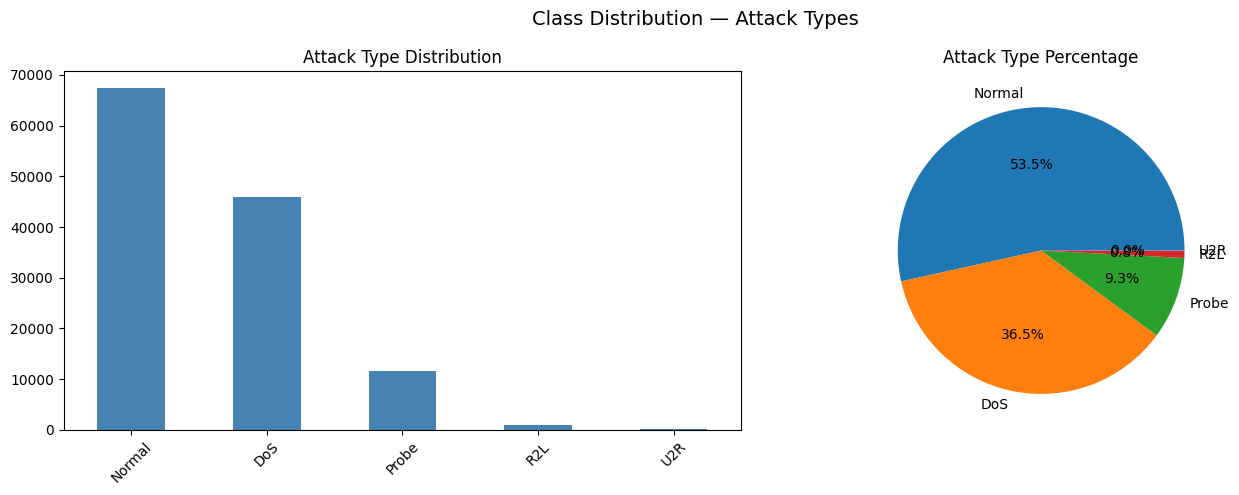

In [19]:
attack_counts = df_train['attack_type'].value_counts()



fig, axes = plt.subplots(1, 2, figsize=(14, 5))



attack_counts.plot(kind='bar', ax=axes[0], color='steelblue')

axes[0].set_title('Attack Type Distribution')

axes[0].set_xlabel('')

axes[0].tick_params(axis='x', rotation=45)



attack_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')

axes[1].set_title('Attack Type Percentage')

axes[1].set_ylabel('')



plt.suptitle('Class Distribution — Attack Types', fontsize=14)

plt.tight_layout()

plt.savefig('../images/class_distribution.png', dpi=150)

plt.show()

> ## *Class Distribution Conclusion*
- **Severe class imbalance** detected
- Normal: 53.5% | DoS: 36.5% | Probe: 9.3%
- R2L: 0.8% | U2R: **0.04%** ← critical minority
- Accuracy metric unreliable — will use **F1 Weighted Score**

## 8. Test Data Sanity Check
> Note:  Only missing values and duplicates checked.
>   Test data is unseen data — full EDA not performed.

In [20]:
# Check missing values
print("Test Missing Values:")
print(df_test.isnull().sum().sum())

# Check duplicate records
print(f"\nTest Duplicates: {df_test.duplicated().sum()}")

# Check dataset shape
print(f"\nTest Shape: {df_test.shape}")

# Check attack type distribution
print("\nTest Attack Distribution:")
print(df_test['attack_type'].value_counts())

Test Missing Values:
0

Test Duplicates: 0

Test Shape: (22544, 44)

Test Attack Distribution:
attack_type
Normal    9711
DoS       7458
R2L       2889
Probe     2421
U2R         65
Name: count, dtype: int64


> ## *Test Data Conclusion*
- Shape: (22,544, 44) ✅
- Missing Values: 0 ✅
- Duplicates: 0 ✅
- All 5 attack types present ✅
- **Test data is clean and ready for model evaluation**

## 9. Preprocessing

### Steps:
- Drop `label` and `difficulty` columns (not needed for training)
- Apply **separate** Label Encoders for each categorical feature
- Save encoders for FastAPI deployment

### Categorical Columns:
| Column | Type | Action |
|---|---|---|
| `protocol_type` | string | LabelEncoder → saved as `le_protocol.pkl` |
| `service` | string | LabelEncoder → saved as `le_service.pkl` |
| `flag` | string | LabelEncoder → saved as `le_flag.pkl` |

> **Note:** Separate encoders used (not loop) to preserve
> each encoder object for FastAPI inference.

In [21]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Remove unnecessary columns
drop_cols = ['label', 'difficulty']
df_train = df_train.drop(columns=drop_cols)
df_test = df_test.drop(columns=drop_cols)

# Create separate LabelEncoder objects for each categorical feature
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

# Fit the encoder on the training data and transform both train and test data
df_train['protocol_type'] = le_protocol.fit_transform(df_train['protocol_type'])
df_test['protocol_type'] = le_protocol.transform(df_test['protocol_type'])

df_train['service'] = le_service.fit_transform(df_train['service'])
df_test['service'] = le_service.transform(df_test['service'])

df_train['flag'] = le_flag.fit_transform(df_train['flag'])
df_test['flag'] = le_flag.transform(df_test['flag'])

# Save the fitted encoders for use in the FastAPI application
joblib.dump(le_protocol, BASE_DIR / "model" / "le_protocol.pkl")
joblib.dump(le_service,  BASE_DIR / "model" / "le_service.pkl")
joblib.dump(le_flag,     BASE_DIR / "model" / "le_flag.pkl")

print("✅ Preprocessing complete!")
print("✅ le_protocol saved!")
print("✅ le_service saved!")
print("✅ le_flag saved!")
print(f"Train Shape: {df_train.shape}")
print(f"Test Shape:  {df_test.shape}")

✅ Preprocessing complete!
✅ le_protocol saved!
✅ le_service saved!
✅ le_flag saved!
Train Shape: (125973, 42)
Test Shape:  (22544, 42)


## Save Processed Data

In [22]:
df_train.to_csv(BASE_DIR / "data" / "processed" / "train_processed.csv", index=False)
df_test.to_csv(BASE_DIR / "data" / "processed" / "test_processed.csv", index=False)
print("✅ Processed data saved!")

✅ Processed data saved!


## **Exploratory Data Analysis Completed ✅**
### Dataset Overview
| Check | Train | Test |
|---|---|---|
| Shape | (125,973, 44) | (22,544, 44) |
| Missing Values | 0 | 0 |
| Duplicates | 0 | 0 |
| Attack Types | 5 | 5 |

### Key Findings
- **Data Quality:** No missing values, no duplicates — clean dataset
- **Outliers:** Present in `src_bytes`, `dst_bytes`, `duration` — represent real attack traffic, retained
- **Class Imbalance:** Severe — U2R only 0.04% — F1 Weighted Score will be used
- **Categorical Features:** 3 columns — Label Encoding will be applied
- **Multicollinearity:** Present but acceptable for tree-based models
- **Feature Distributions:** All key features show extreme right skew

### Attack Type Distribution
| Class | Train | Test |
|---|---|---|
| Normal | 67,343 (53.5%) | 9,711 |
| DoS | 45,927 (36.5%) | 7,458 |
| Probe | 11,656 (9.3%) | 2,421 |
| R2L | 995 (0.8%) | 2,889 |
| U2R | 52 (0.04%) | 65 |

### Next Step
➡️ **02_Model_Training.ipynb**   Model Training